<a href="https://colab.research.google.com/github/vn-tnt-cnx/3DAircraft-Maint-Vision/blob/main/amv_RF-DETR_Datasetv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How to Train RF-DETR Object Detection on a Custom Dataset


RF-DETR is a real-time, transformer-based object detection model architecture developed by Roboflow and released under the Apache 2.0 license.

![rf-detr-coco-rf100-vl-8](https://media.roboflow.com/rf-detr/charts.png)

RF-DETR is the first real-time model to exceed 60 AP on the [Microsoft COCO benchmark](https://cocodataset.org/#home) alongside competitive performance at base sizes. It also achieves state-of-the-art performance on [RF100-VL](https://github.com/roboflow/rf100-vl), an object detection benchmark that measures model domain adaptability to real world problems. RF-DETR is comparable speed to current real-time objection models.

![rf-detr-coco-results-2](https://media.roboflow.com/rf-detr/example_grid.png)

RF-DETR is small enough to run on the edge, making it an ideal model for deployments that need both strong accuracy and real-time performance.

## Environment setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Configure your API keys

To download model weights, you need to provide your HuggingFace Token. Follow these steps:

- Open your [`HuggingFace Settings`](https://huggingface.co/settings) page. Click `Access Tokens` then `New Token` to generate new token.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store HuggingFace Access Token under the name `HF_TOKEN`.

In [ ]:
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Mon May  5 09:59:12 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

### Install dependencies

Install the RF-DETR SDK

To get started, we need to install the RF-DETR SDK. You can install the SDK with the following command:



In [ ]:
!pip install -q rfdetr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 18.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

## Download Dataset from Roboflow

https://universe.roboflow.com/muhammadmoin-arxtl/potholes-detection-jbnou/dataset/1

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="qcRjBsTtcUqzVPgkEMFR")
project = rf.workspace("congnx").project("window-class-3-3-25")
version = project.version(8)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Window-class-3/3/25-8 in coco:: 100%|██████████| 663/663 [00:00<00:00, 5368.97it/s]


In [ ]:
dataset.location

'/content/Window-class-3/3/25-8'

## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

### Train with multiple GPUs

You can fine-tune RF-DETR on multiple GPUs using PyTorch’s Distributed Data Parallel (DDP). Create a `main.py` script that initializes your model and calls `.train()` as usual than run it in terminal.

```bash
python -m torch.distributed.launch \
    --nproc_per_node=8 \
    --use_env \
    main.py
```

Replace `8` in the `--nproc_per_node argument` with the number of GPUs you want to use. This approach creates one training process per GPU and splits the workload automatically. Note that your effective batch size is multiplied by the number of GPUs, so you may need to adjust your `batch_size` and `grad_accum_steps` to maintain the same overall batch size.

In [ ]:
from rfdetr import RFDETRBase

model = RFDETRBase()
history = []

def callback2(data):
    history.append(data)

model.callbacks["on_fit_epoch_end"].append(callback2)

# model.train(dataset_dir=dataset.location, epochs=250, batch_size=16, grad_accum_steps=1, lr=1e-4)

rf-detr-base.pth: 100%|██████████| 355M/355M [00:16<00:00, 23.0MiB/s]


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading pretrain weights


reinitializing your detection head with 3 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=3, grad_accum_steps=1, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=16, weight_decay=0.0001, epochs=250, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads

Streaming output truncated to the last 5000 lines.
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.920
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.937
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.801
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.983
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
Grad accum steps:  1
Total batch size:  16
LENGTH OF DATA LOADER: 33
Epoch: [146]  [ 0/33]  eta: 0:00:46  lr: 0.000010  class_error: 0.00  loss: 1.5808 (1.5808)  loss_ce: 0.2264 (0.2264)  loss_bbox: 0.0170 (0.0170)  loss_giou: 0.1239 (0.1239)  loss_ce_0: 0.2699 (0.2699)  loss_bbox_0: 0.0173 (0.0173)  loss_giou_0: 0.1248 (0.1248)  loss_ce_1: 0.2280 (0.2280)  loss_bbox_1: 0.0170 (0.0170)  loss_giou_1: 0.1239 (0.1239)  loss_ce_enc: 0.2694 (0.2694)  loss_bbox_enc: 0.0209 (0.0209)  loss_giou_enc: 0.1423 (0.1423)  loss_ce_unscaled: 0.2264 (0.2264) 

In [ ]:
model

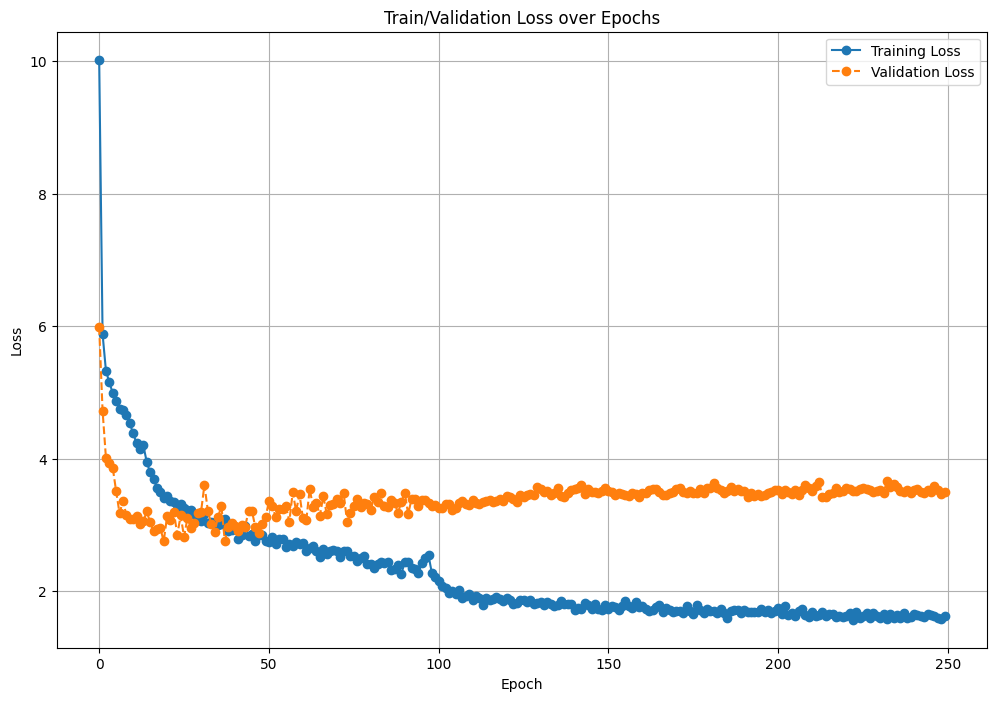

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(history)

plt.figure(figsize=(12, 8))

plt.plot(
    df['epoch'],
    df['train_loss'],
    label='Training Loss',
    marker='o',
    linestyle='-'
)

plt.plot(
    df['epoch'],
    df['test_loss'],
    label='Validation Loss',
    marker='o',
    linestyle='--'
)

plt.title('Train/Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

### Average Precision

The graph below represents the Average Precision (AP) over training epochs across different Intersection Over Union (IOU) thresholds  (0.50 to 0.95, in steps of 0.05).



**Average Precision (AP)**

Average Precision (AP) is a key metric used to evaluate object detection models. It measures how well a model detects objects across different confidence thresholds by considering both precision and recall.

**Understanding Precision & Recall**

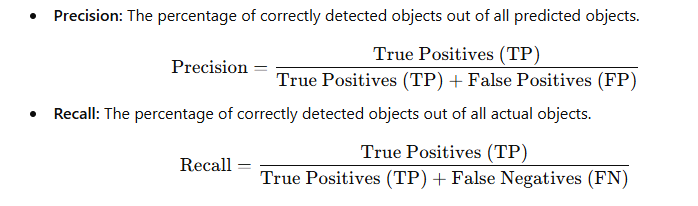

**How AP is Calculated**

**Precision-Recall (PR) Curve:**

The model predicts objects at different confidence scores (thresholds).

A Precision-Recall Curve is plotted by varying the threshold and computing precision vs. recall.

**Compute AP:**

The AP is the area under the Precision-Recall (PR) curve.

Higher AP means better object detection performance.

**AP (IoU=0.50:0.95) Meaning**

IoU (Intersection over Union) measures how much the predicted bounding box overlaps with the ground truth.

AP at IoU 0.50:0.95 is the mean AP calculated at multiple IoU thresholds (0.50 to 0.95, in steps of 0.05).



**Key Takeaways**

Good Model Performance: The AP value around 0.60 is relatively high, indicating decent object detection capability.

Training Convergence: The model stops improving significantly after ~10 epochs, meaning further training may not bring substantial gains.

### Average Recall

The graph below represents the Average Recall (AR) over training epochs across different Intersection Over Union (IOU) thresholds.



The AR starts at a lower value and increases rapidly in the first few epochs.

It then stabilizes around 0.32 - 0.34, with minor fluctuations.

The trend suggests the model is learning effectively but may still be improving gradually

**Average Recall (AR)** is a metric used in object detection to evaluate the model's ability to detect objects across different Intersection Over Union (IOU) thresholds. It is a mean recall over a range of IOU values, typically from 0.50 to 0.95 with steps of 0.05

**How AR is Calculated**

The recall is measured at multiple IoU thresholds (e.g., 0.50, 0.55, 0.60, ..., 0.95).

The average of these recall values gives the Average Recall (AR).



**Key Concepts**

Recall measures how many true positives the model correctly detects out of the total available ground-truth objects.

IoU (Intersection over Union) is the ratio of the overlapping area between the predicted bounding box and the ground truth box to the union of both areas.

Higher AR indicates that the model detects more objects correctly across various IoU thresholds.

### Results

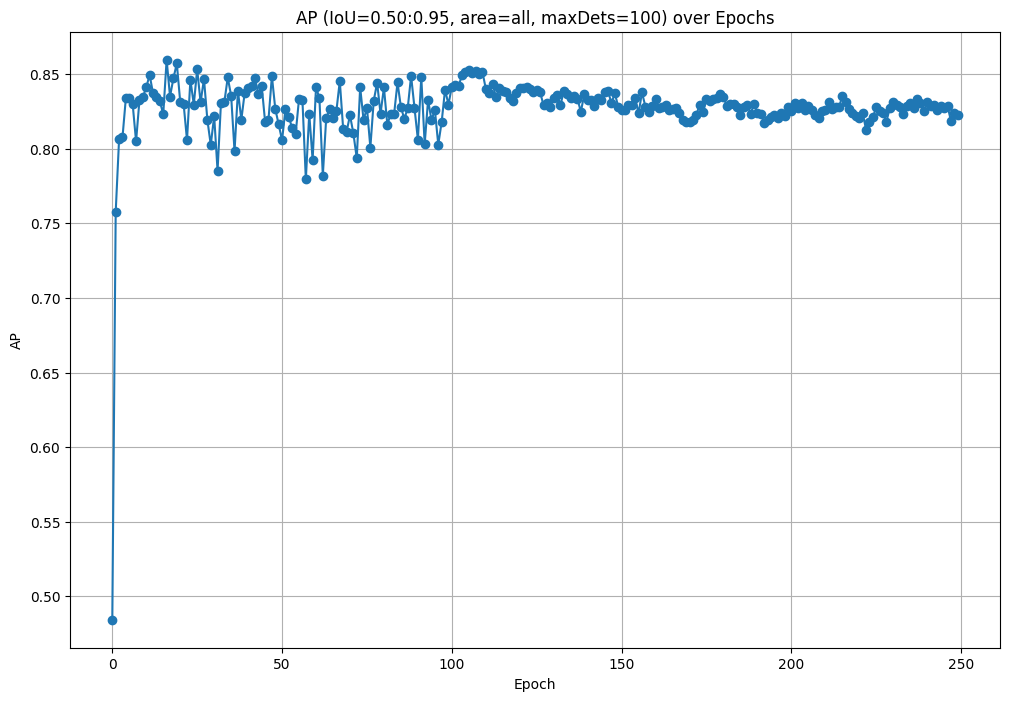

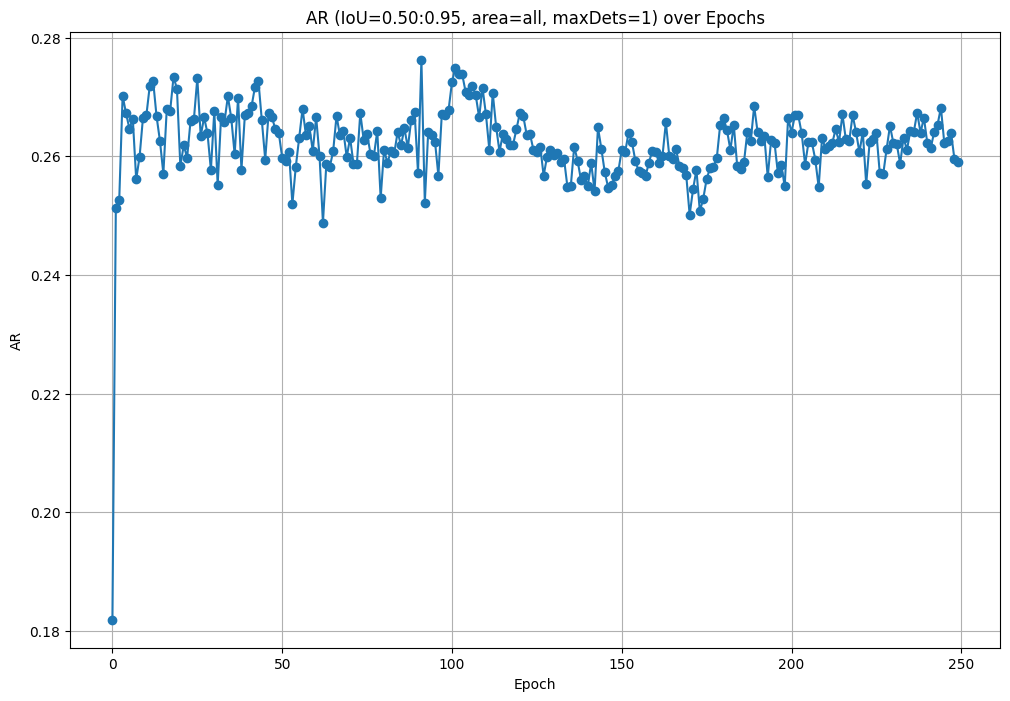

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame(history)

df['avg_precision'] = df['test_coco_eval_bbox'].apply(lambda arr: arr[0])
df['avg_recall'] = df['test_coco_eval_bbox'].apply(lambda arr: arr[6])

plt.figure(figsize=(12, 8))
plt.plot(
    df['epoch'],
    df['avg_precision'],
    marker='o',
    linestyle='-'
)
plt.title('AP (IoU=0.50:0.95, area=all, maxDets=100) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AP')
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 8))
plt.plot(
    df['epoch'],
    df['avg_recall'],
    marker='o',
    linestyle='-'
)
plt.title('AR (IoU=0.50:0.95, area=all, maxDets=1) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('AR')
plt.grid(True)
plt.show()

## Run inference with fine-tuned model

In [ ]:
from rfdetr import RFDETRBase

model = RFDETRBase(pretrain_weights='/content/drive/MyDrive/trained/train_rf-detr_datasetv8_2025-05-05/output/checkpoint_best_regular.pth')


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading pretrain weights


reinitializing detection head with 2 classes


In [ ]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [ ]:
print(len(ds))

64


In [ ]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

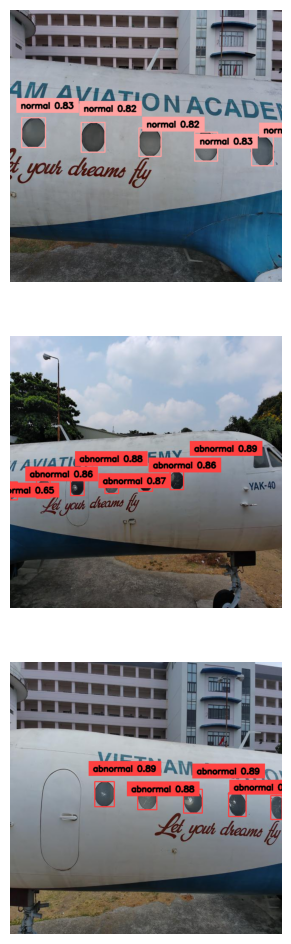

In [ ]:
import supervision as sv
from rfdetr import RFDETRBase
from PIL import Image

detections_images = []

for i in range(3):
    path, image, annotations = ds[i]
    image = Image.open(path)

    detections = model.predict(image, threshold=0.5)

    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
    thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

    bbox_annotator = sv.BoxAnnotator(thickness=thickness)
    label_annotator = sv.LabelAnnotator(
        text_color=sv.Color.BLACK,
        text_scale=text_scale,
        text_thickness=thickness,
        smart_position=True)

    detections_labels = [
        f"{ds.classes[class_id]} {confidence:.2f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]

    detections_image = image.copy()
    detections_image = bbox_annotator.annotate(detections_image, detections)
    detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

    detections_images.append(detections_image)

sv.plot_images_grid(images=detections_images, grid_size=(3, 1))

## Evaluate fine-tuned model

In [ ]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0.5)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 64/64 [00:01<00:00, 32.56it/s]


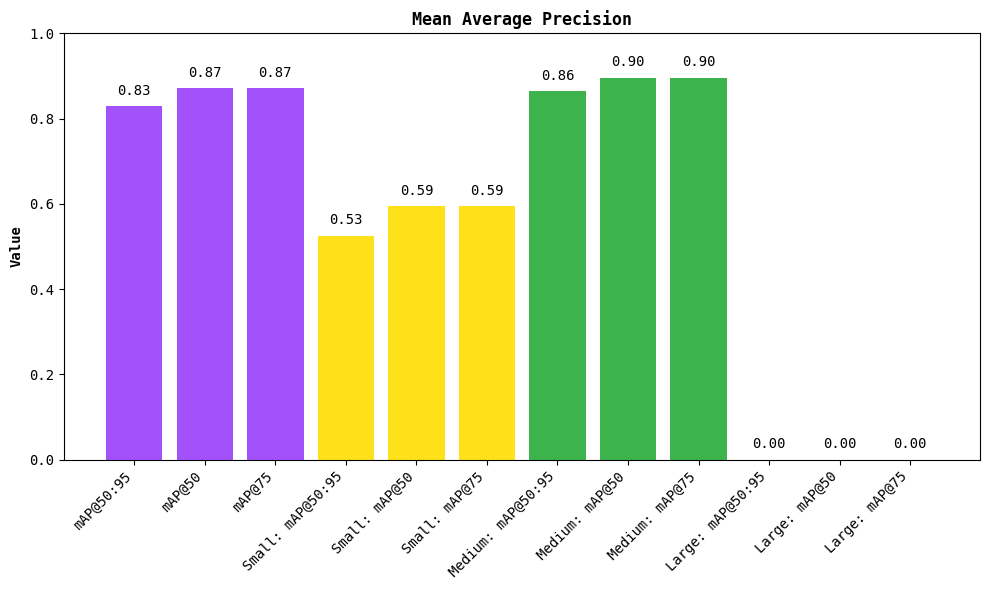

In [ ]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()

map_result.plot()

### Confusion Matrix

Confusion matrix tells us how our model handles different classes.

In the current project, we have only one class pothole


**True Positives (TP):**

The model predicted a label and it matches correctly as per ground truth

**True Negatives (TN):**

The model doesnot predict the label and is not a part of the ground truth


**False Positives (FP):**

The model  predicted a label but it is not a part of the ground truth


**False Negatives (FN):**

The model doesnot predicted a label but it is a part of the ground truth

In [ ]:
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds.classes
)

_ = confusion_matrix.plot()

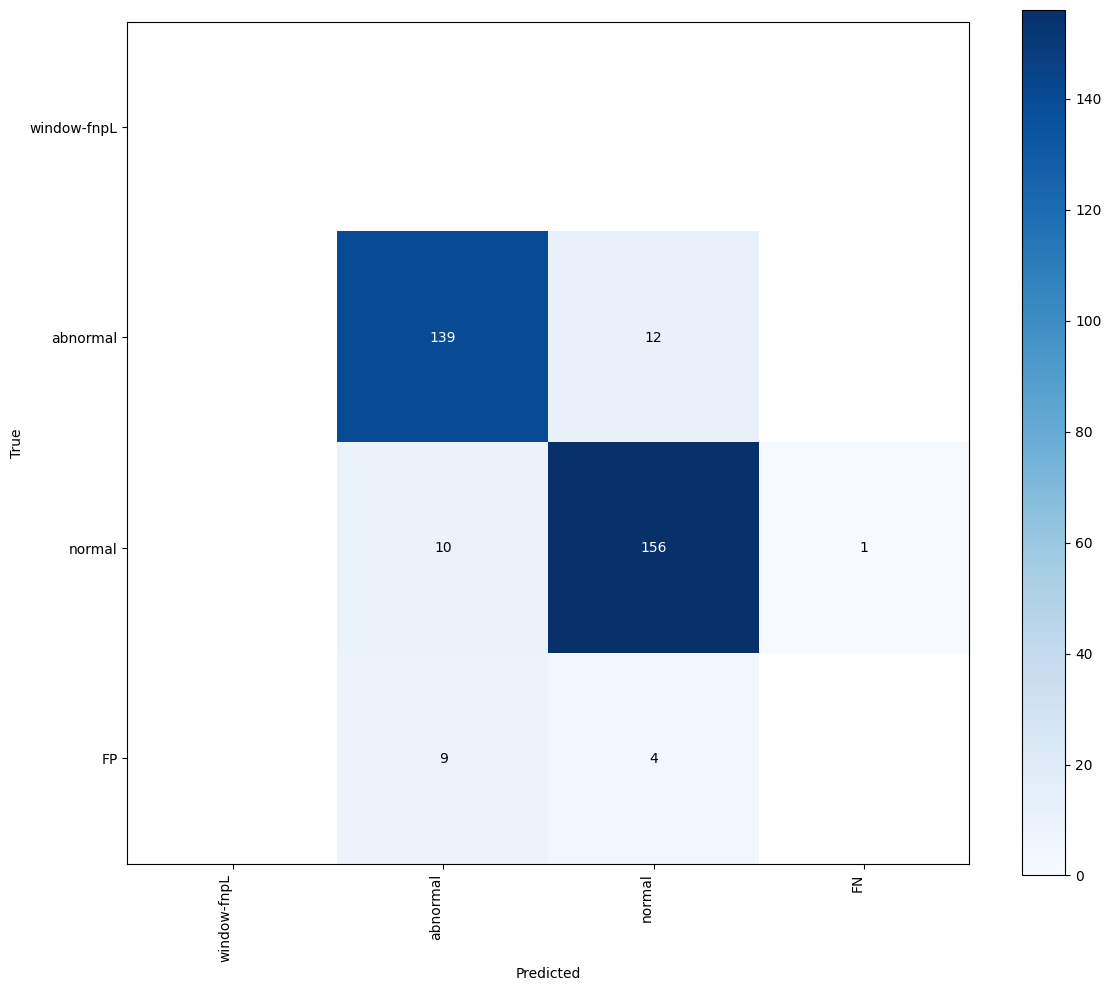

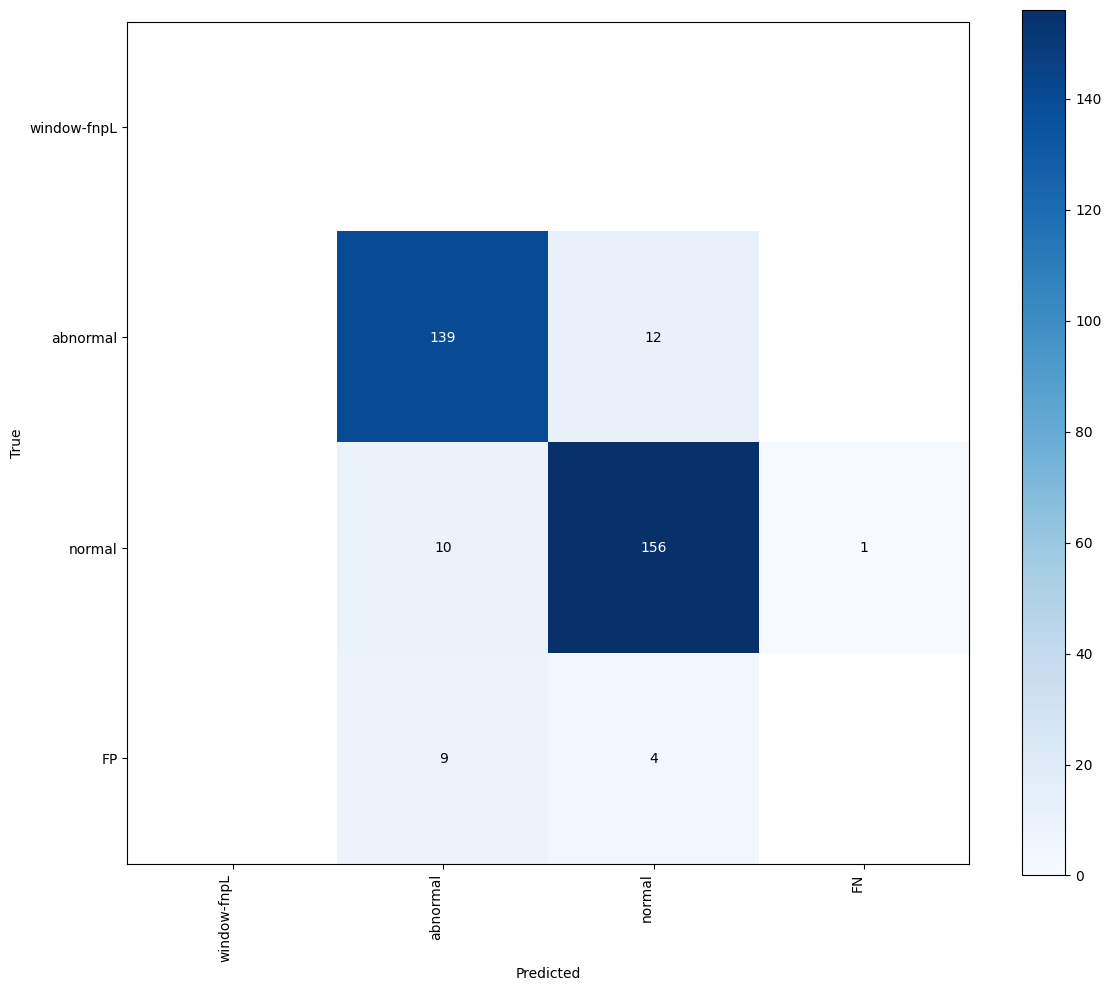

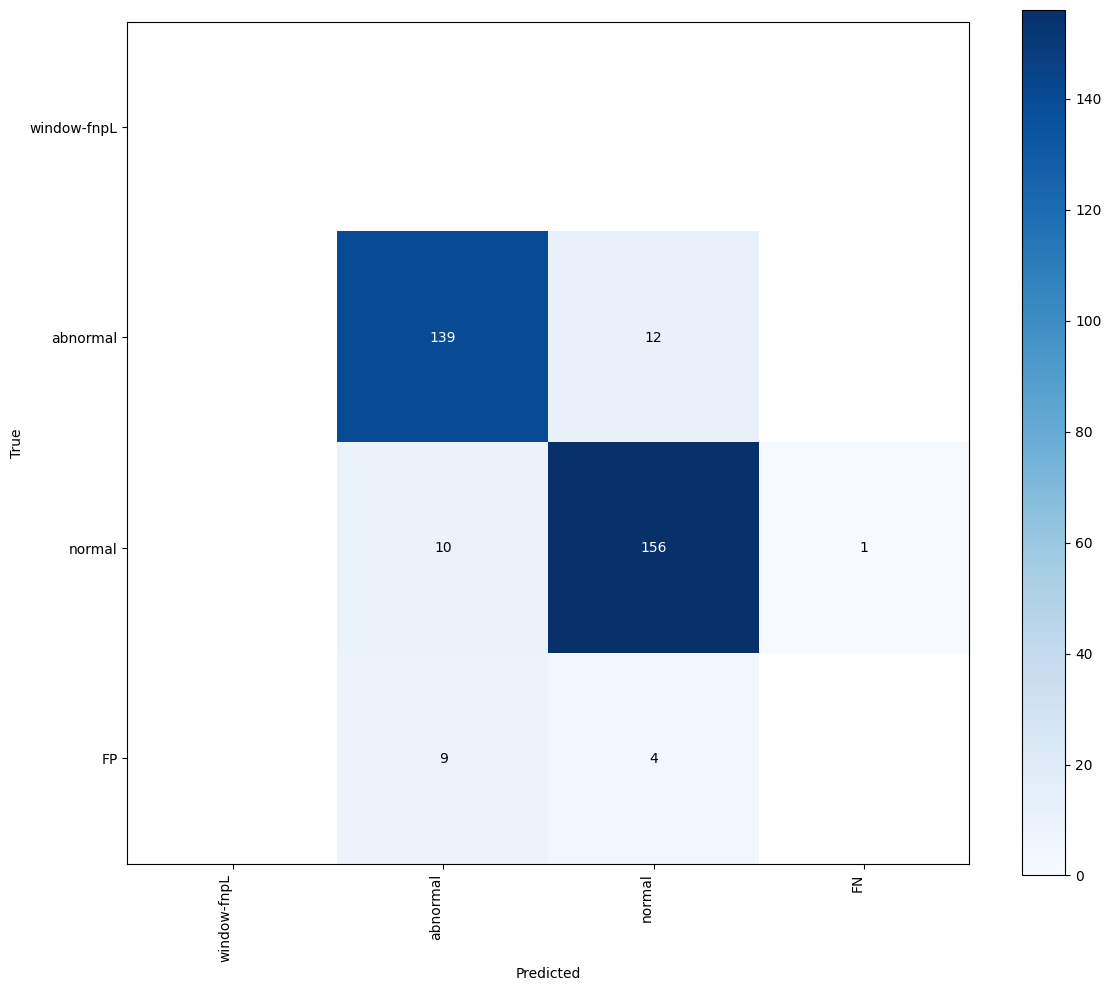

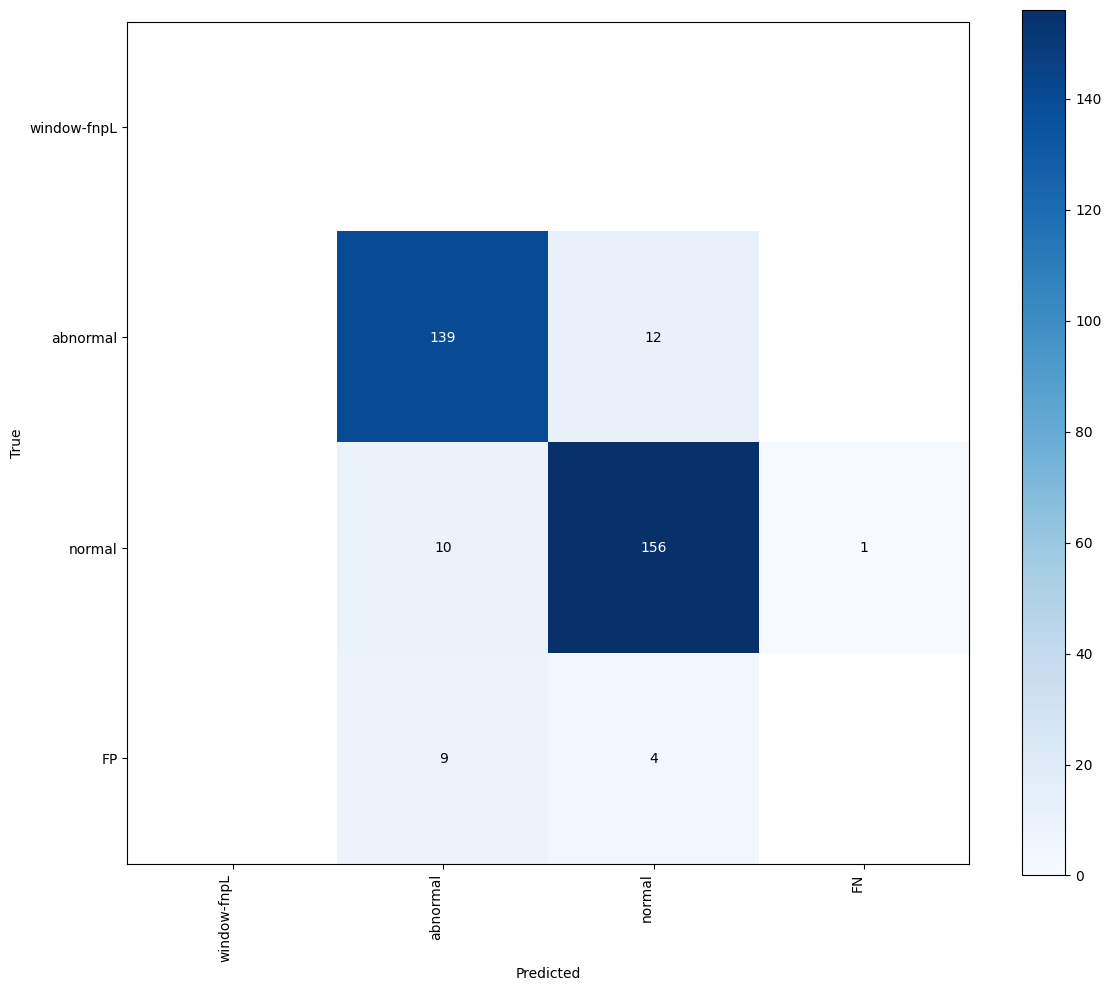

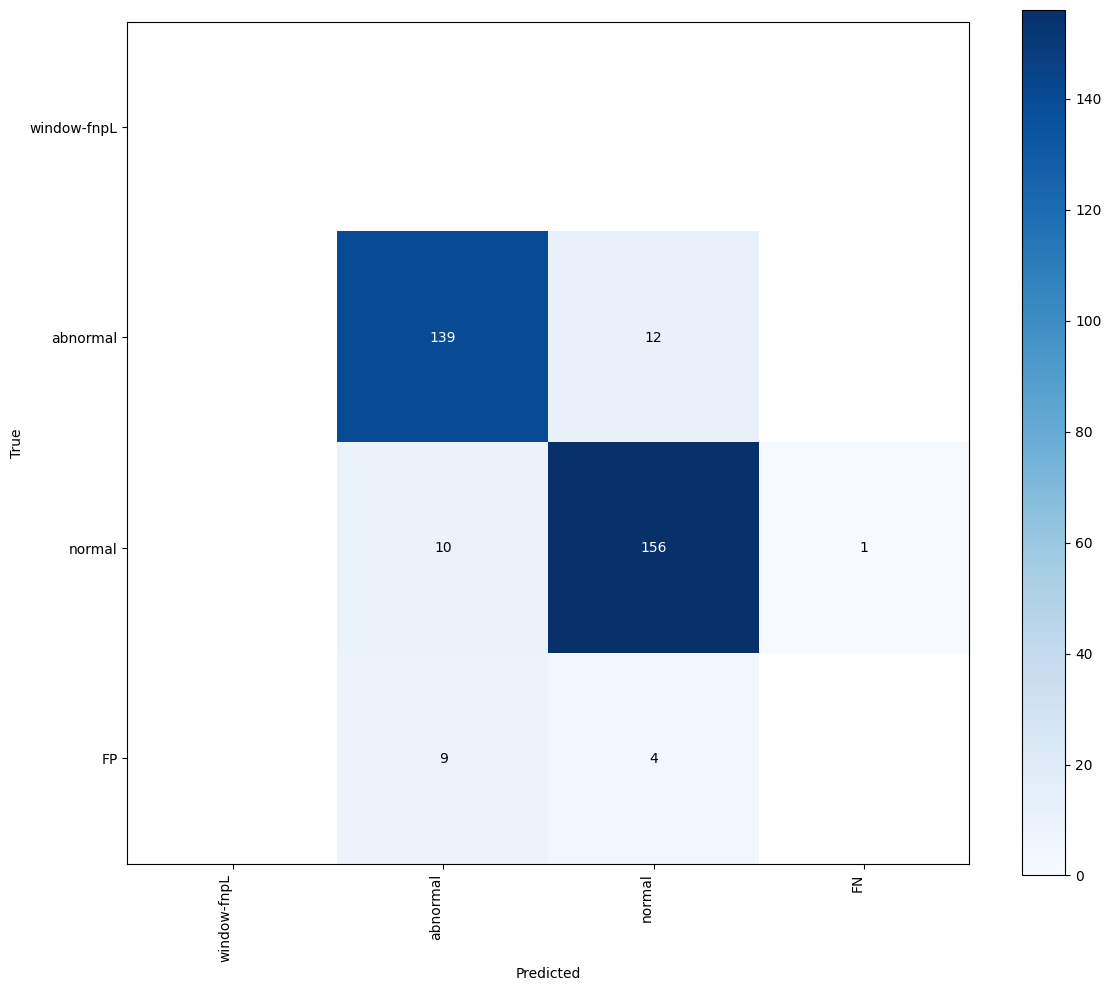

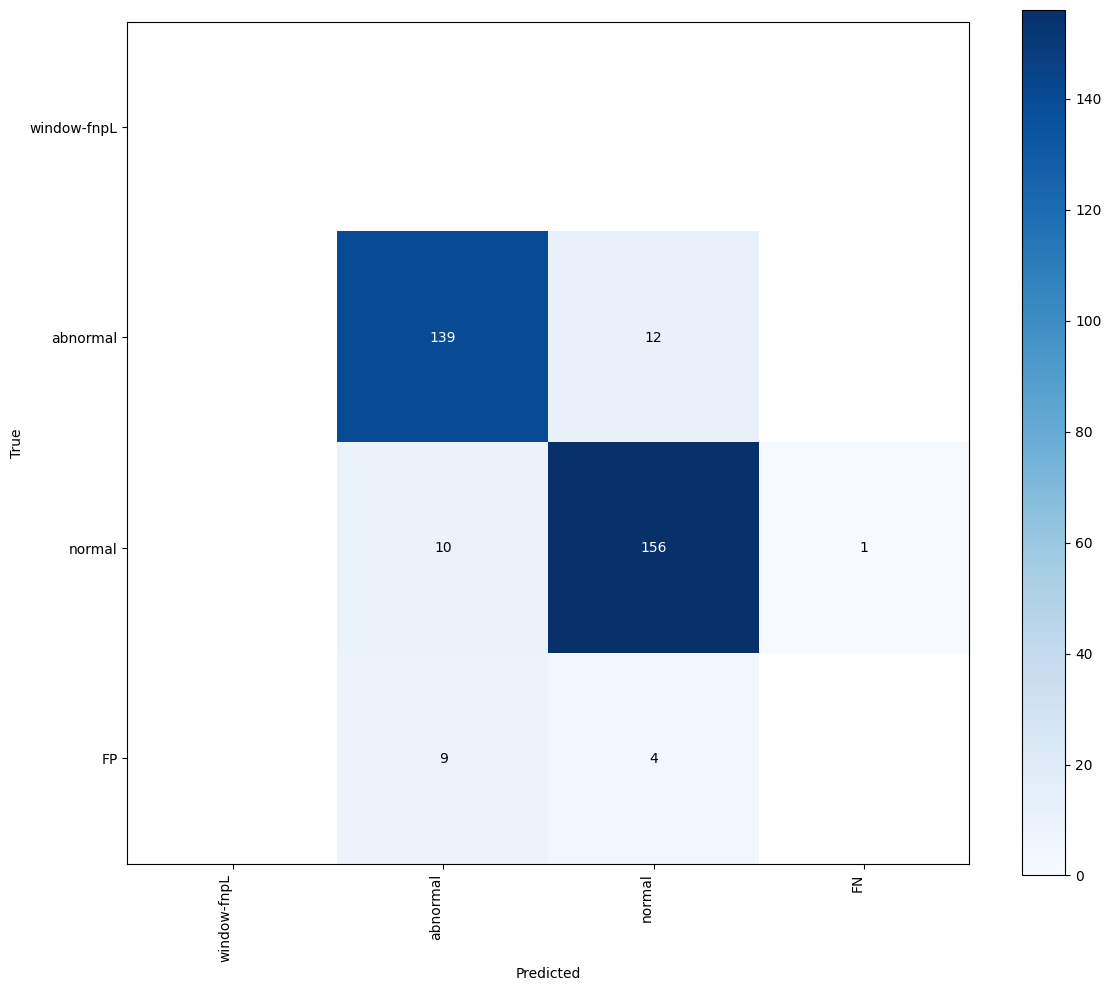

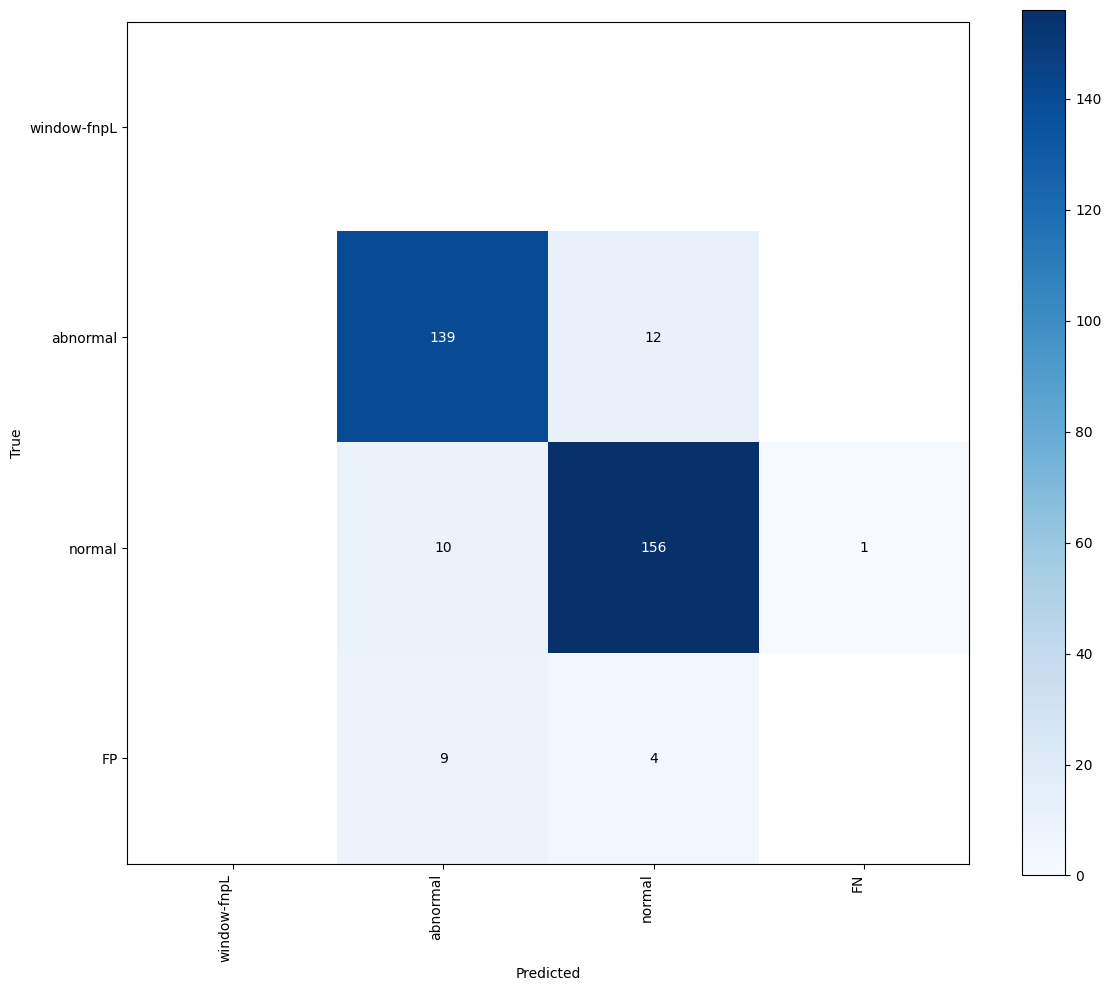

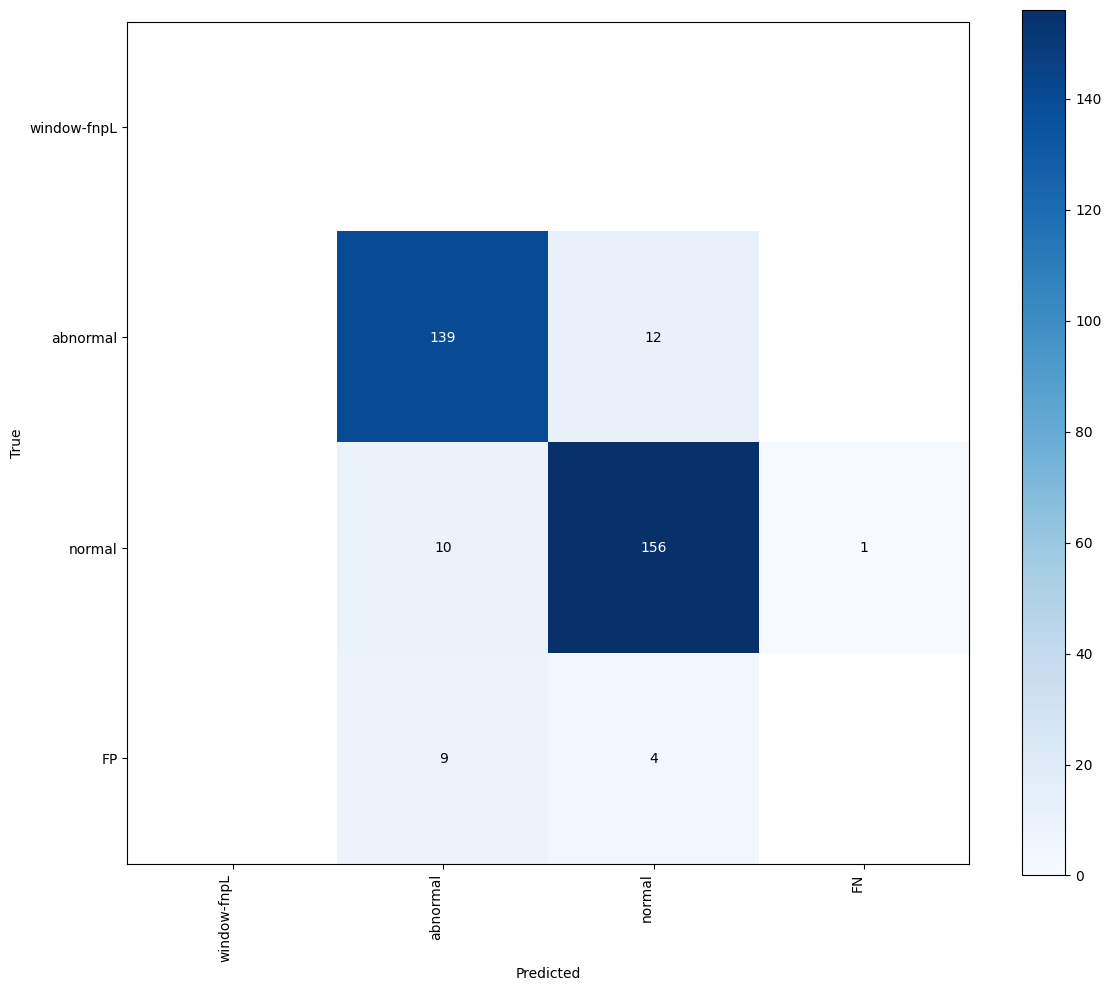

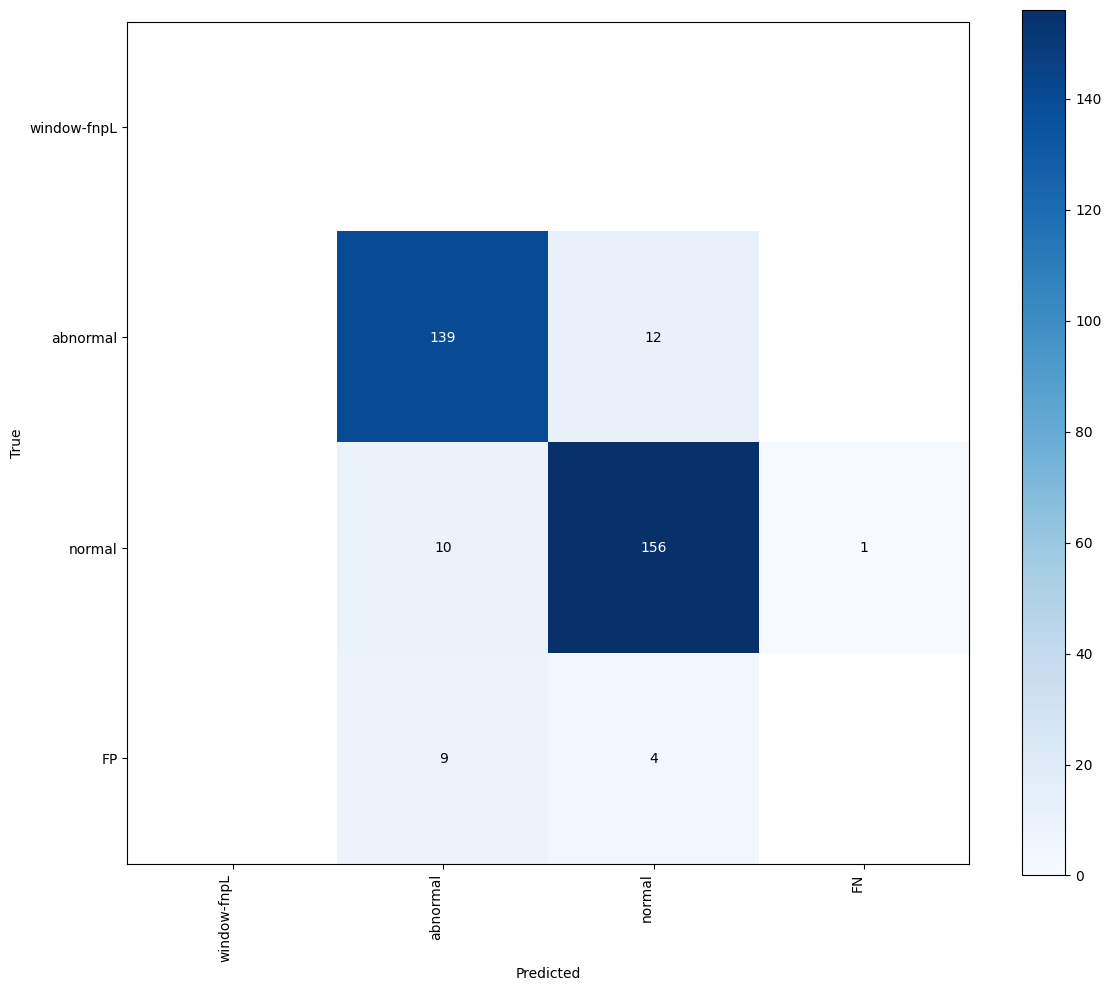

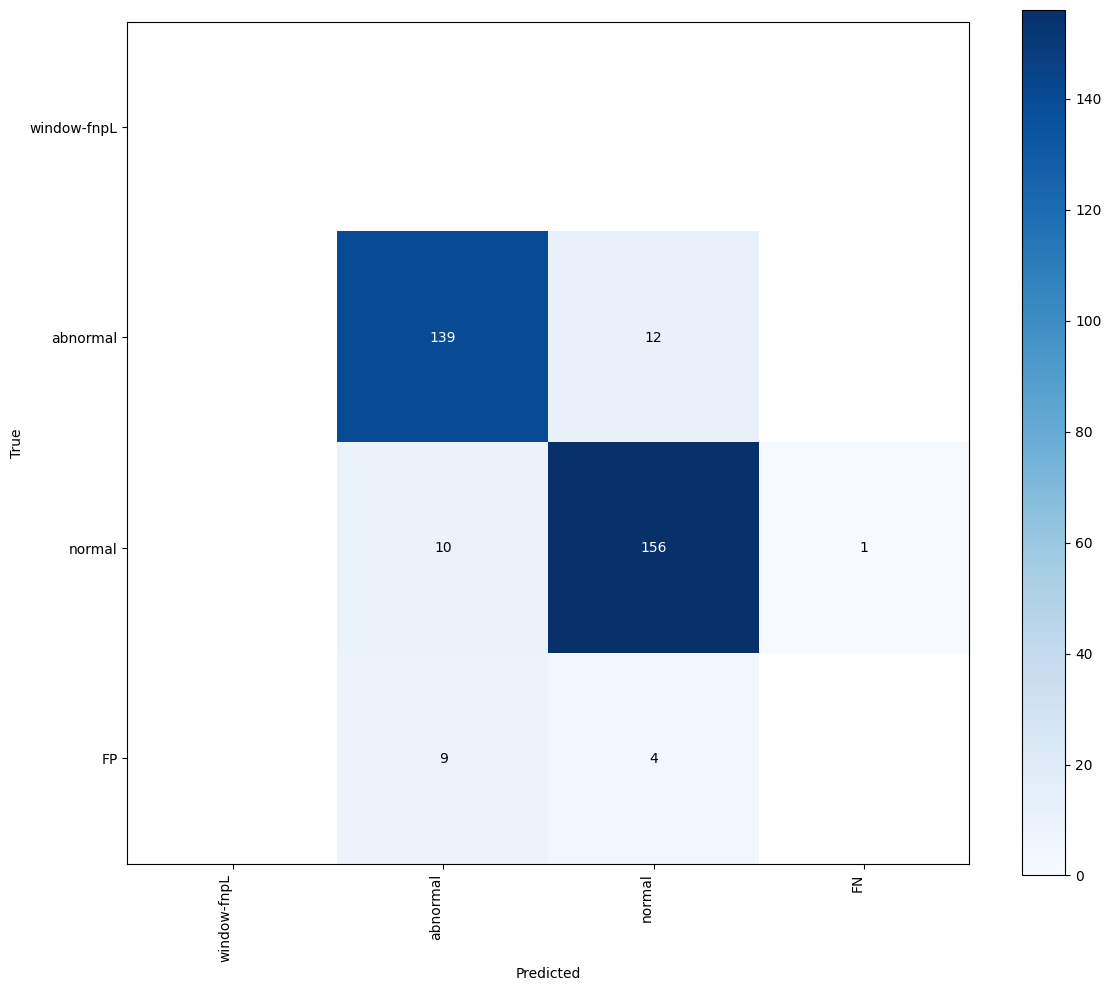

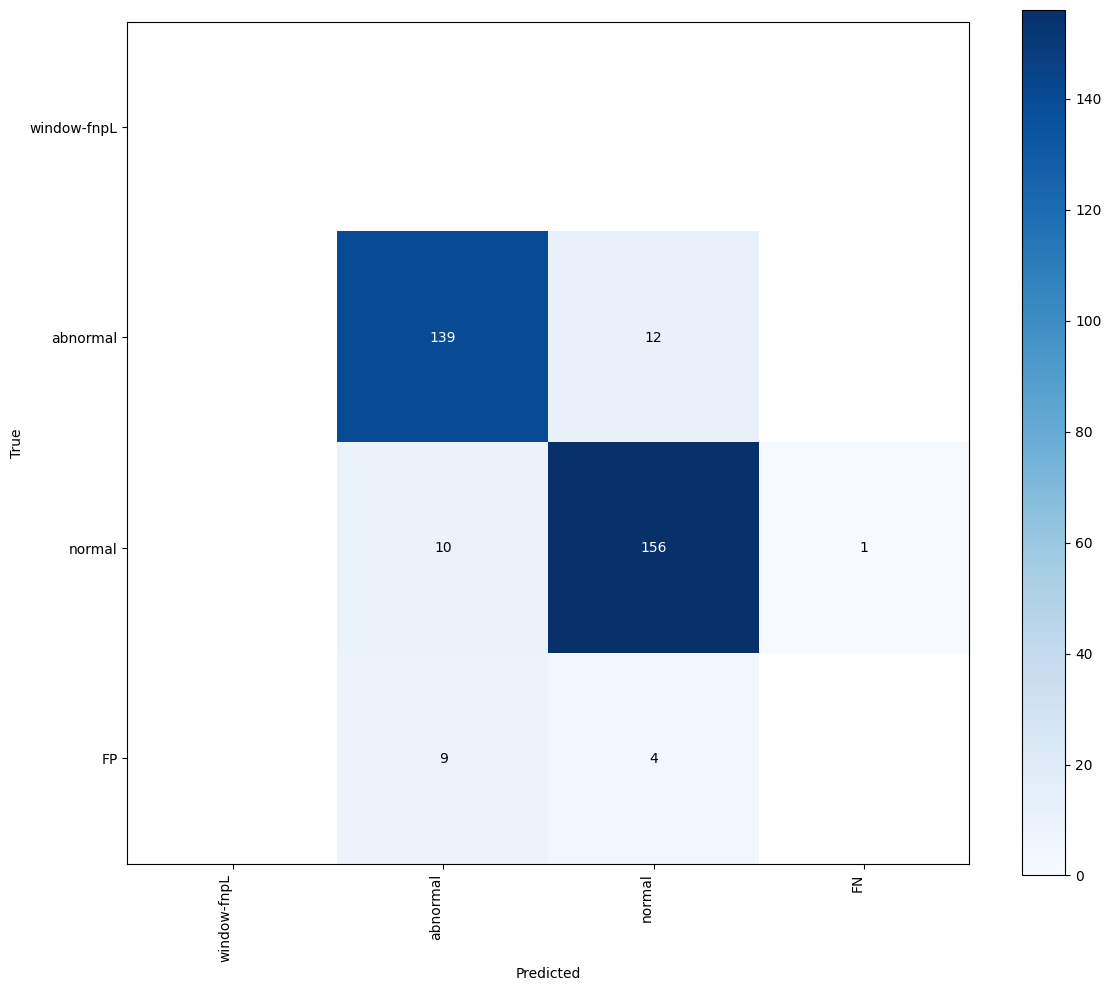

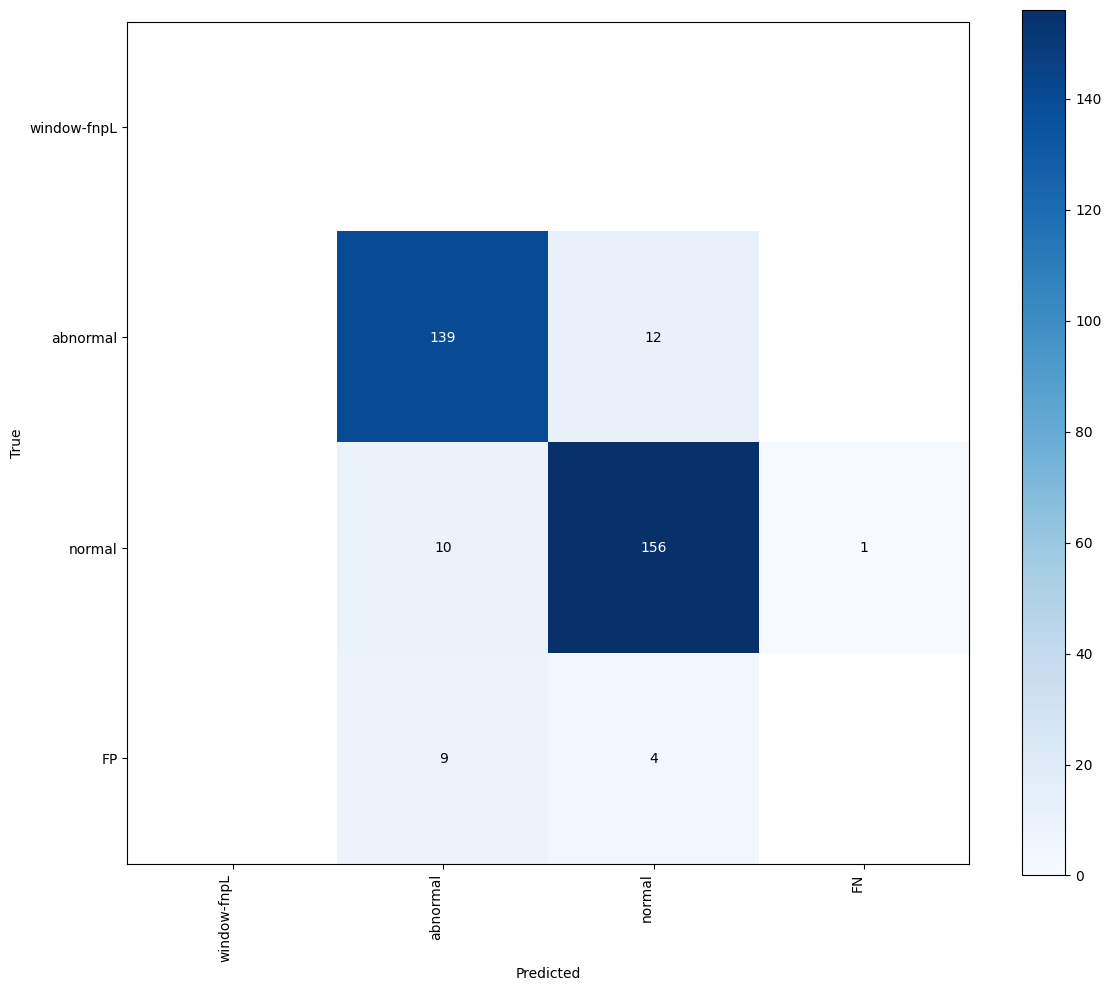

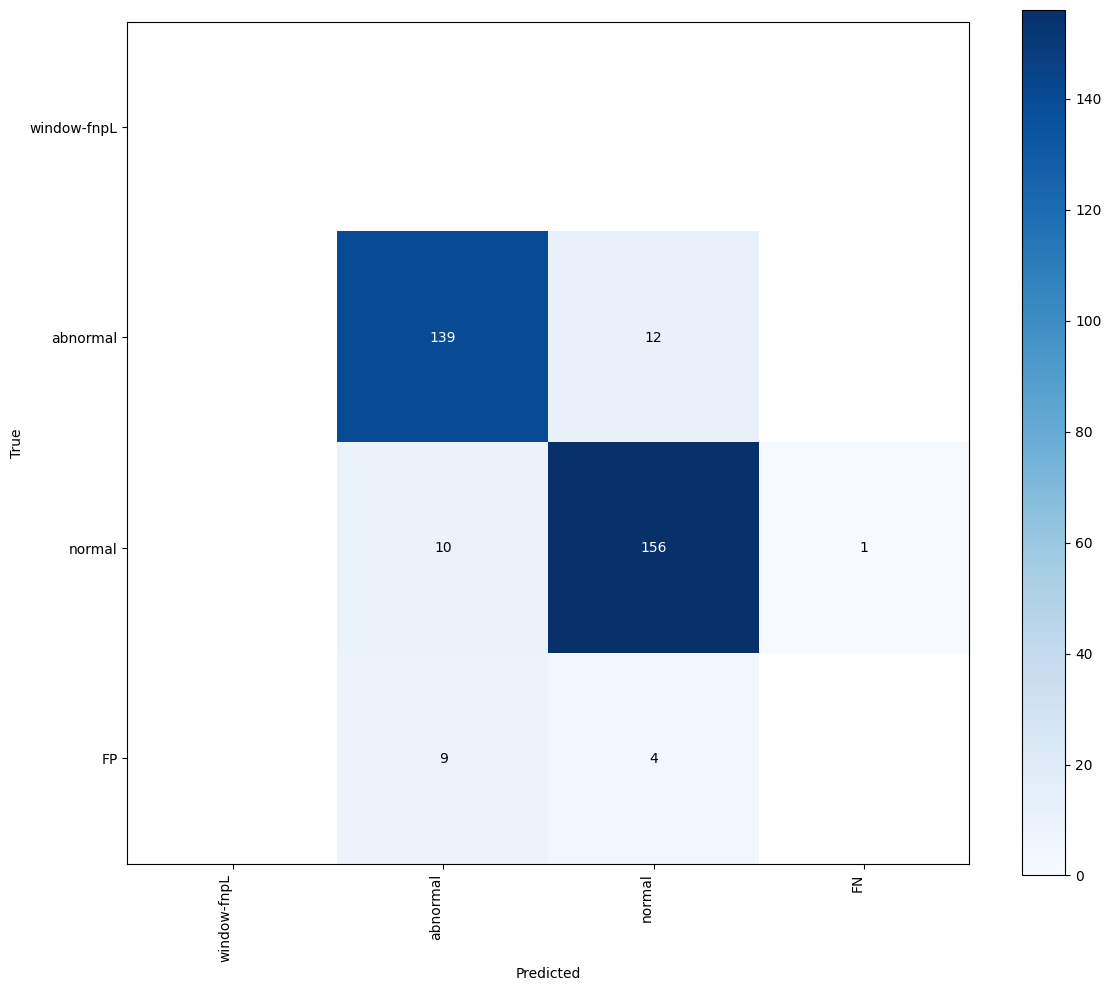

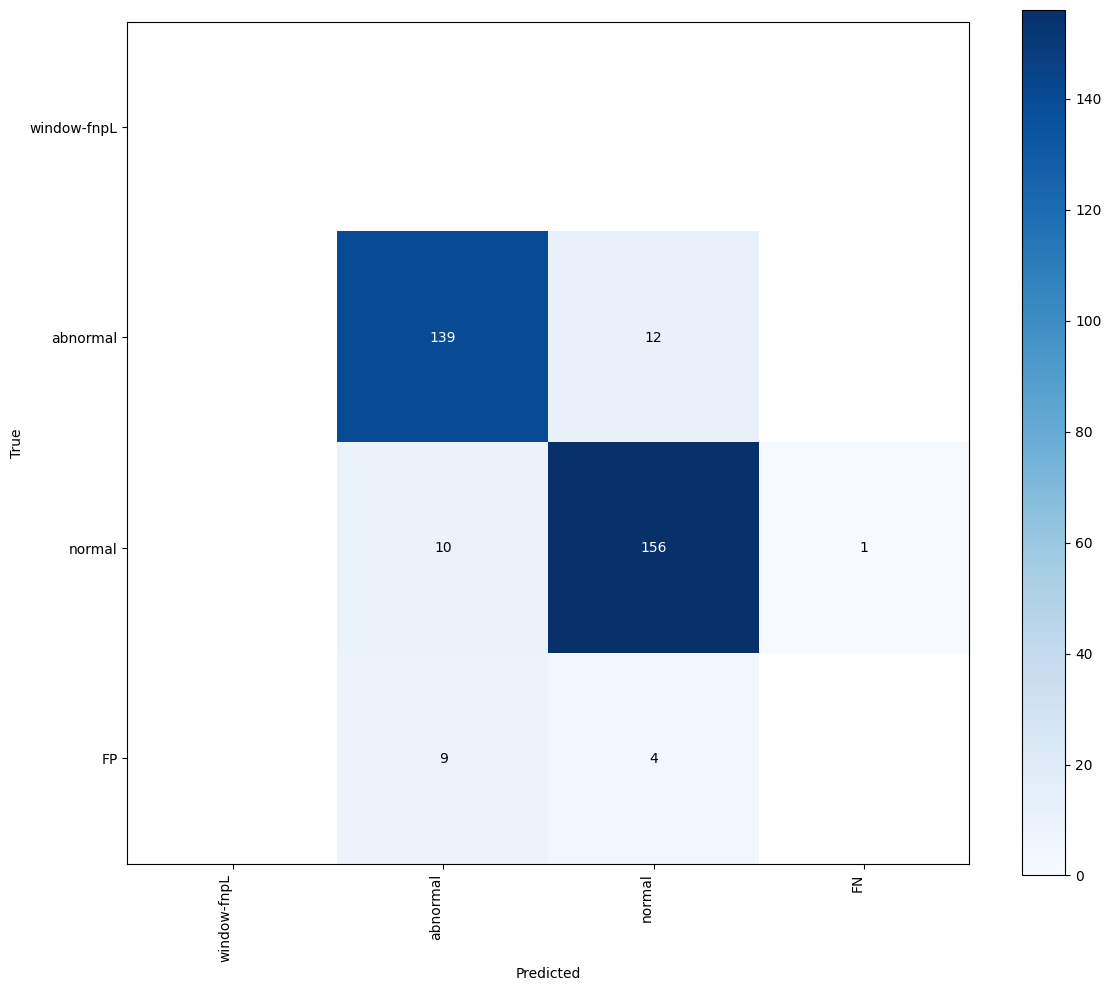

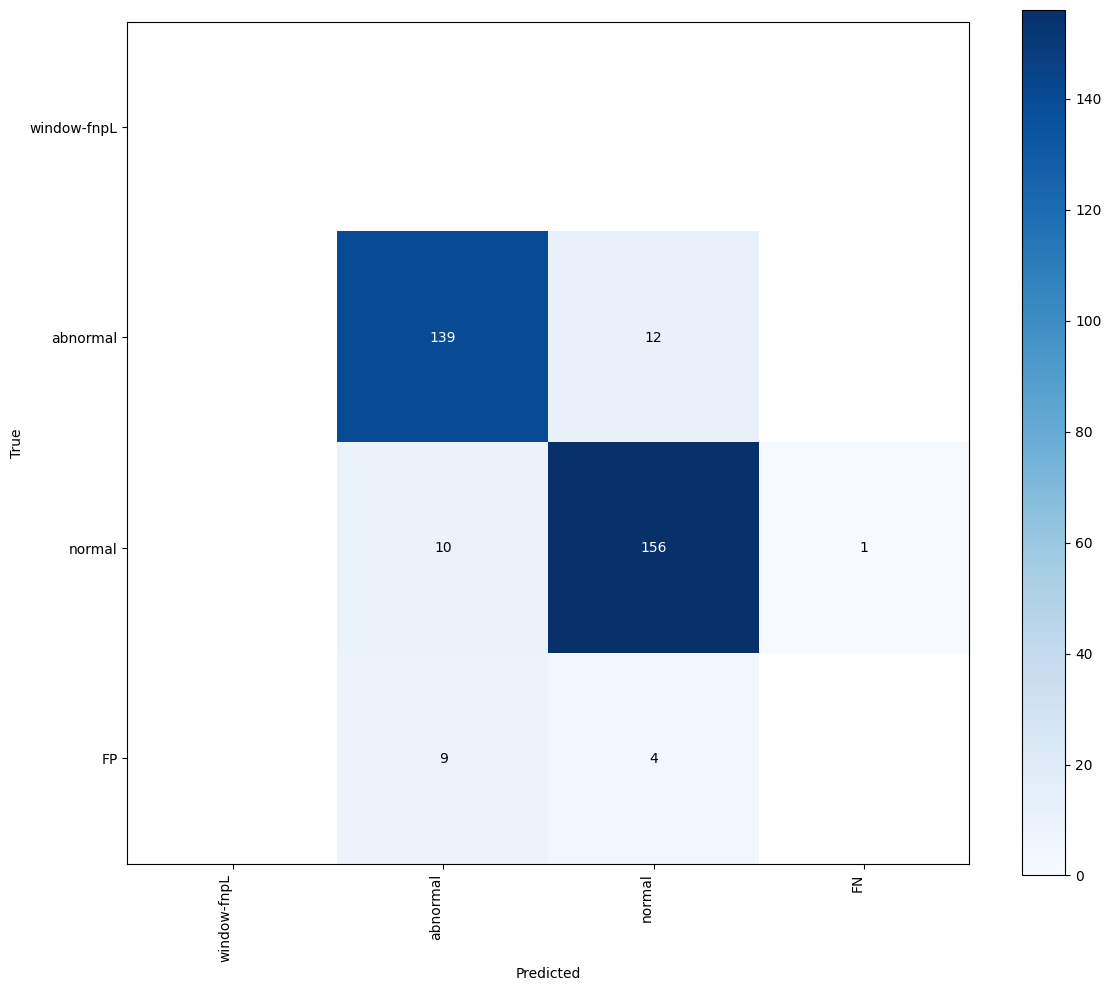

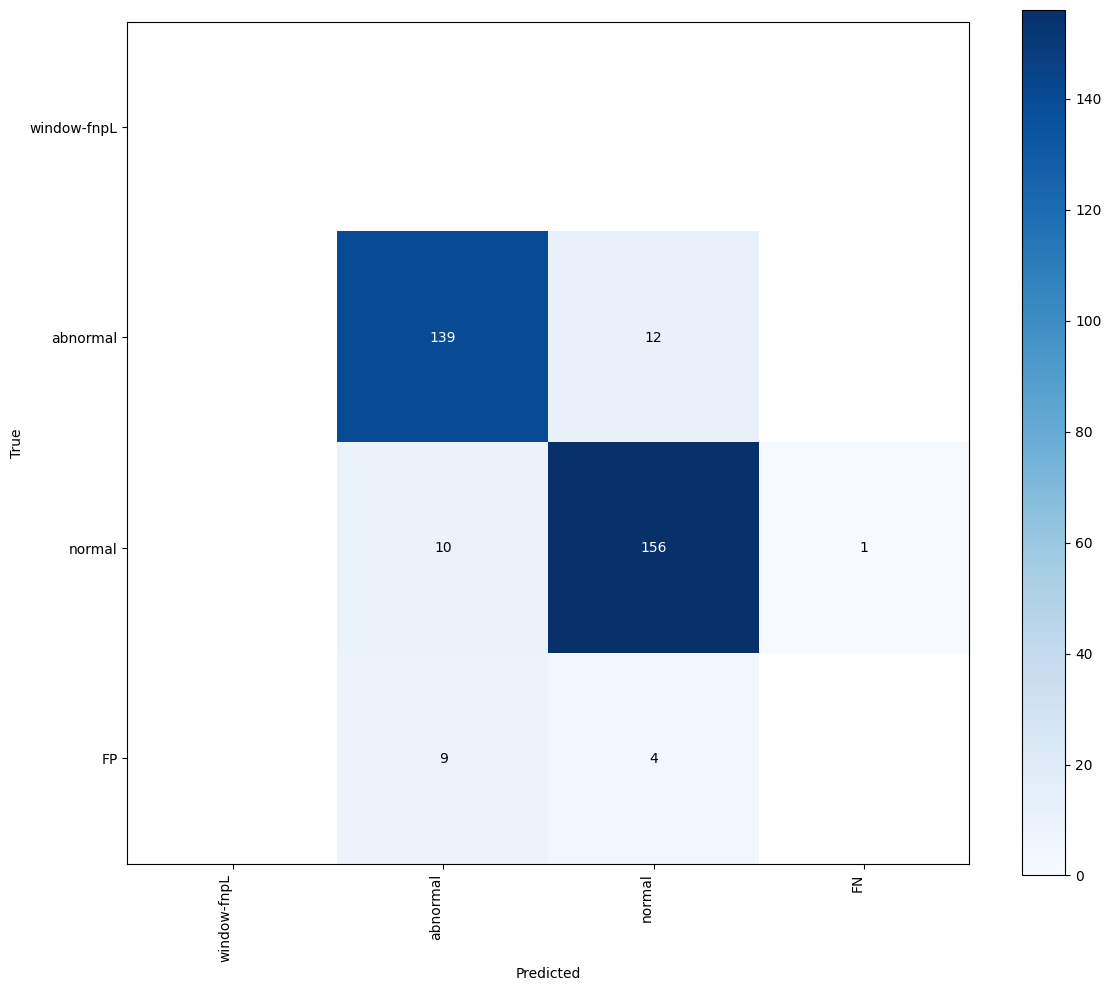

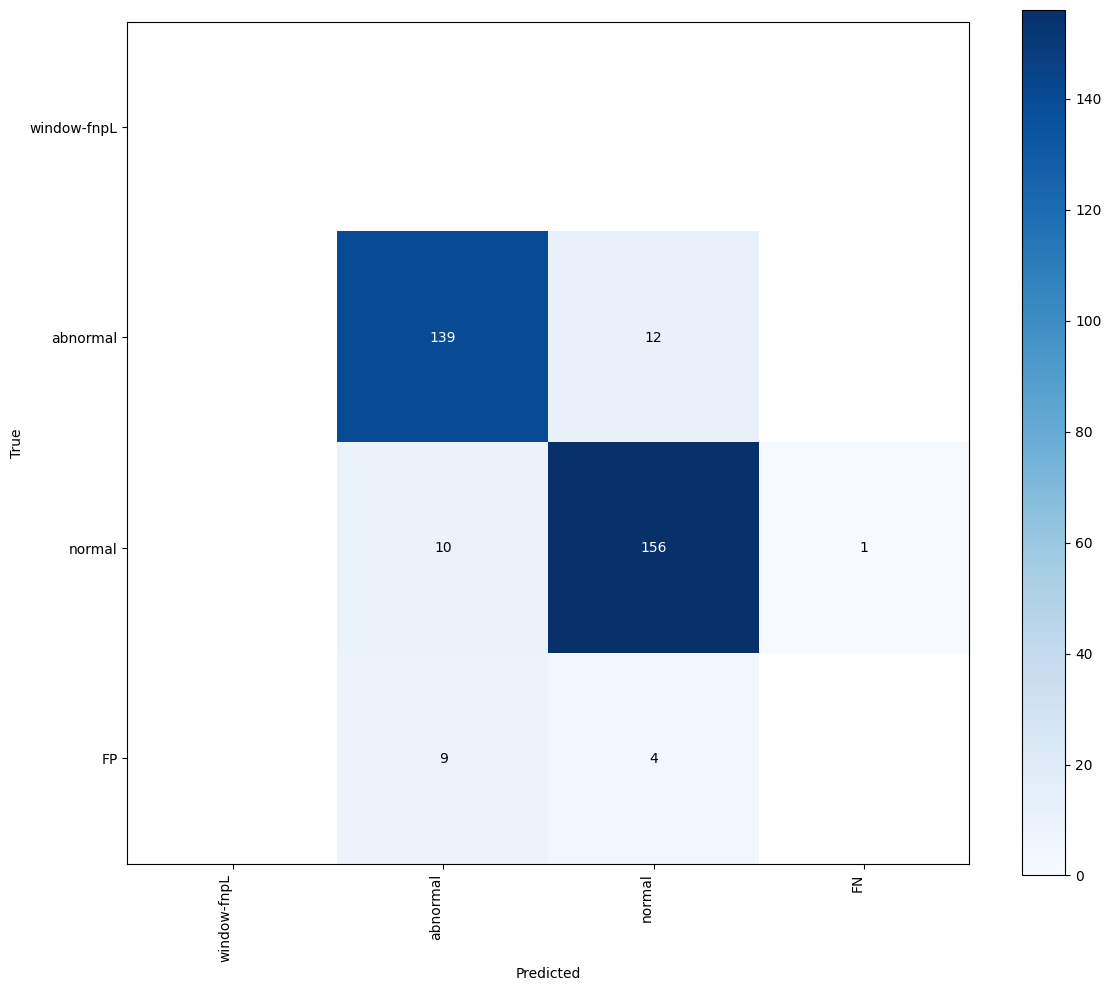

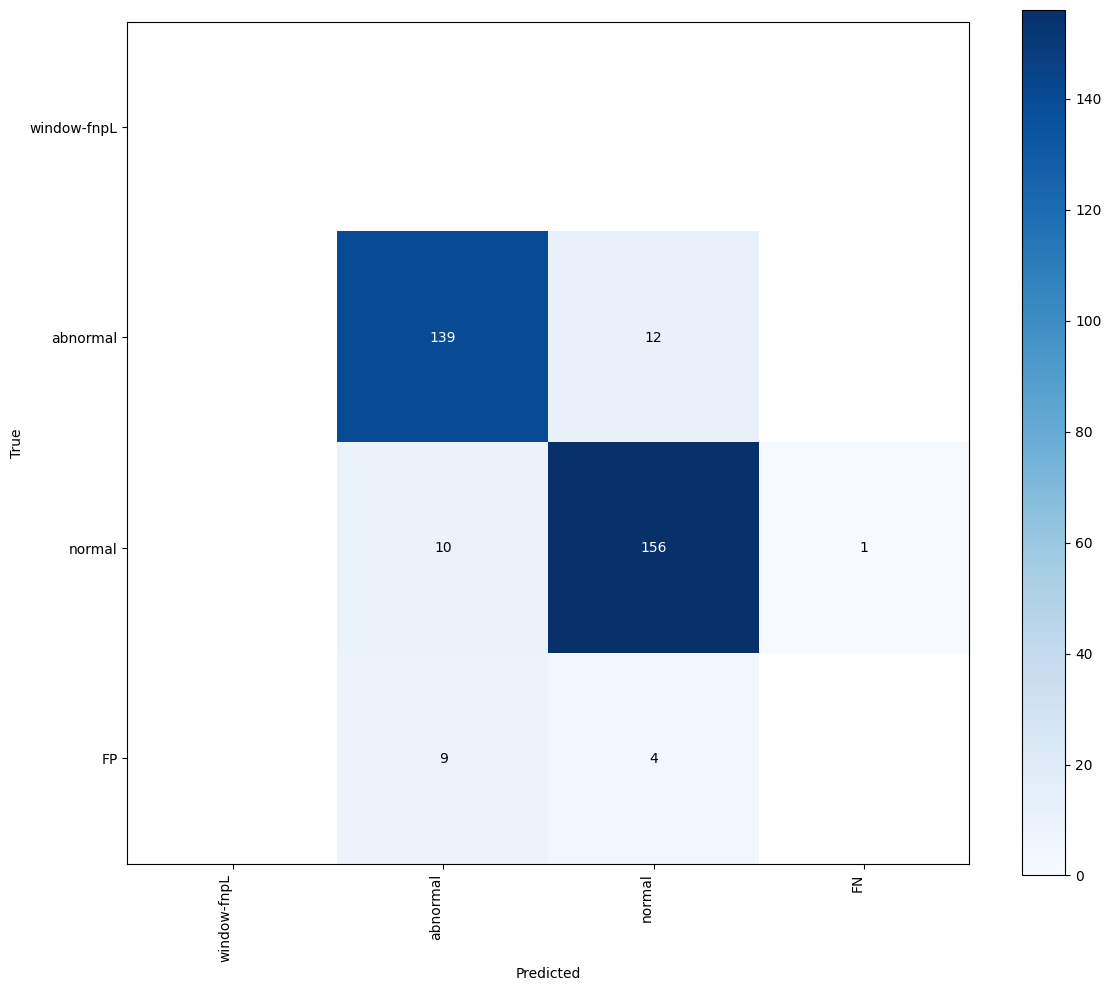

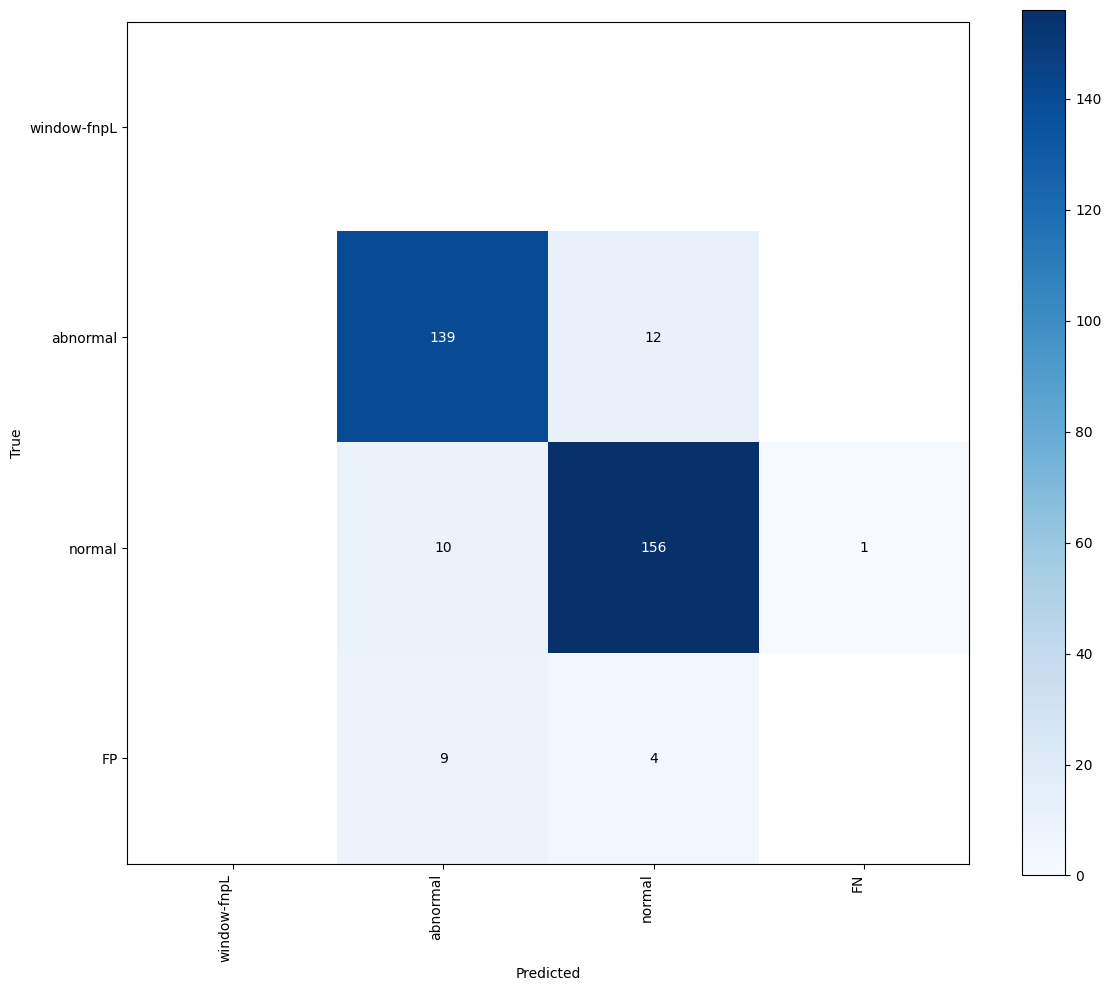

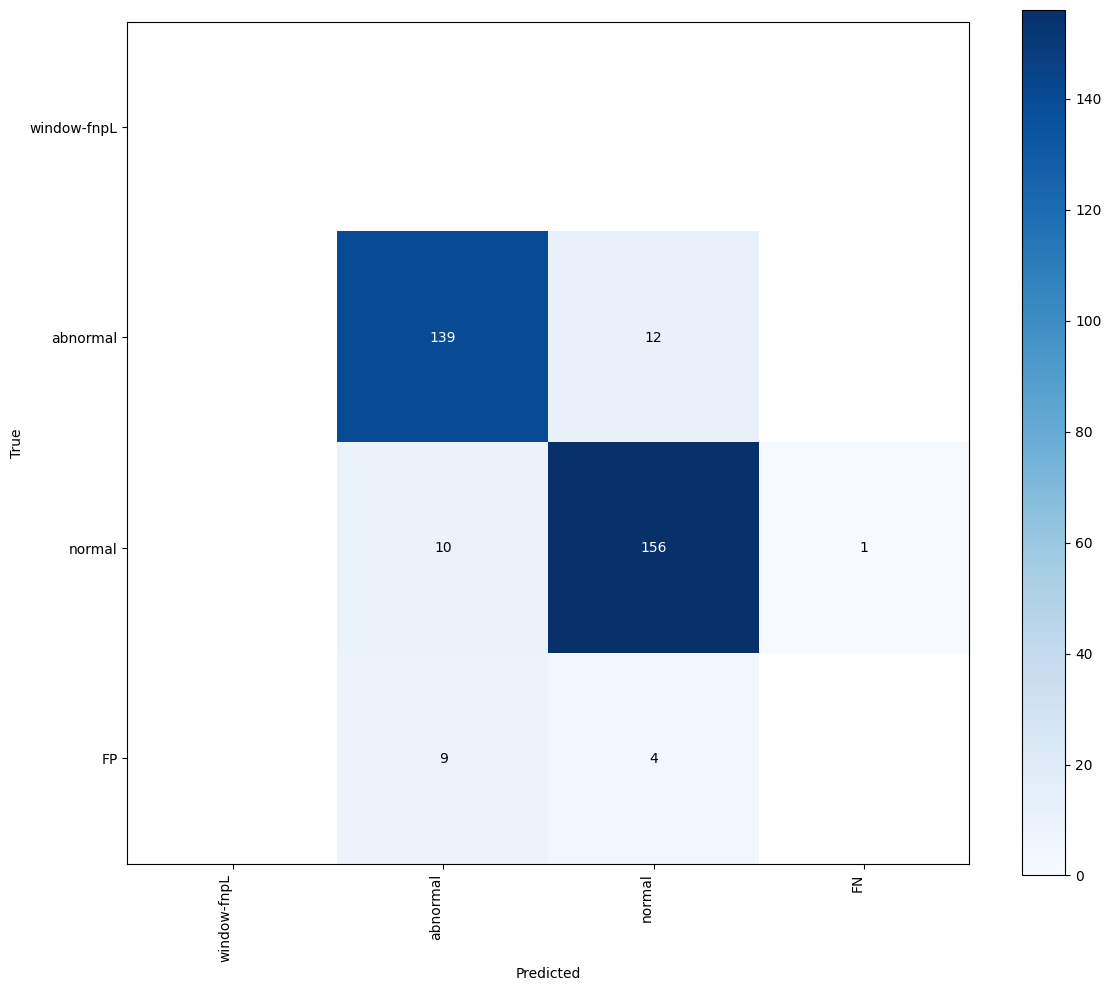

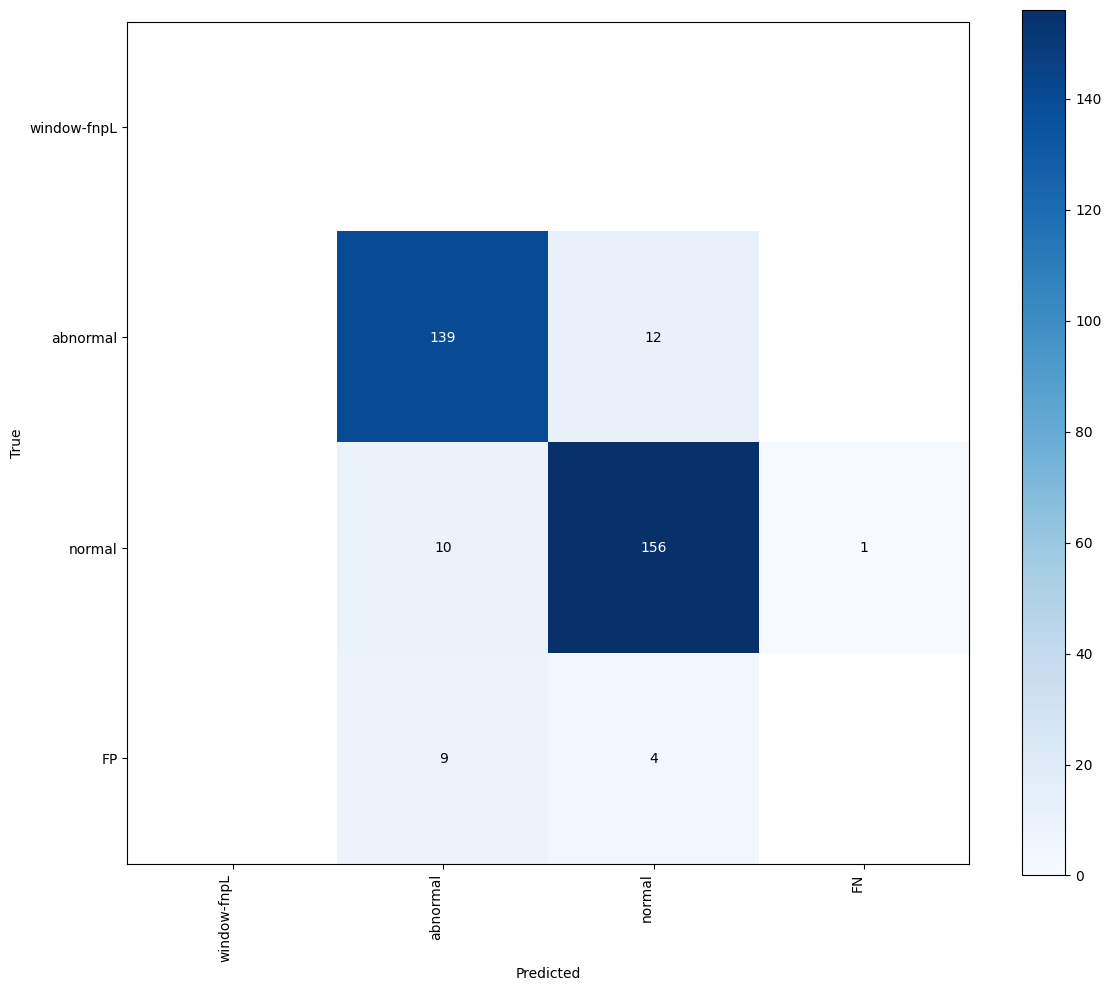

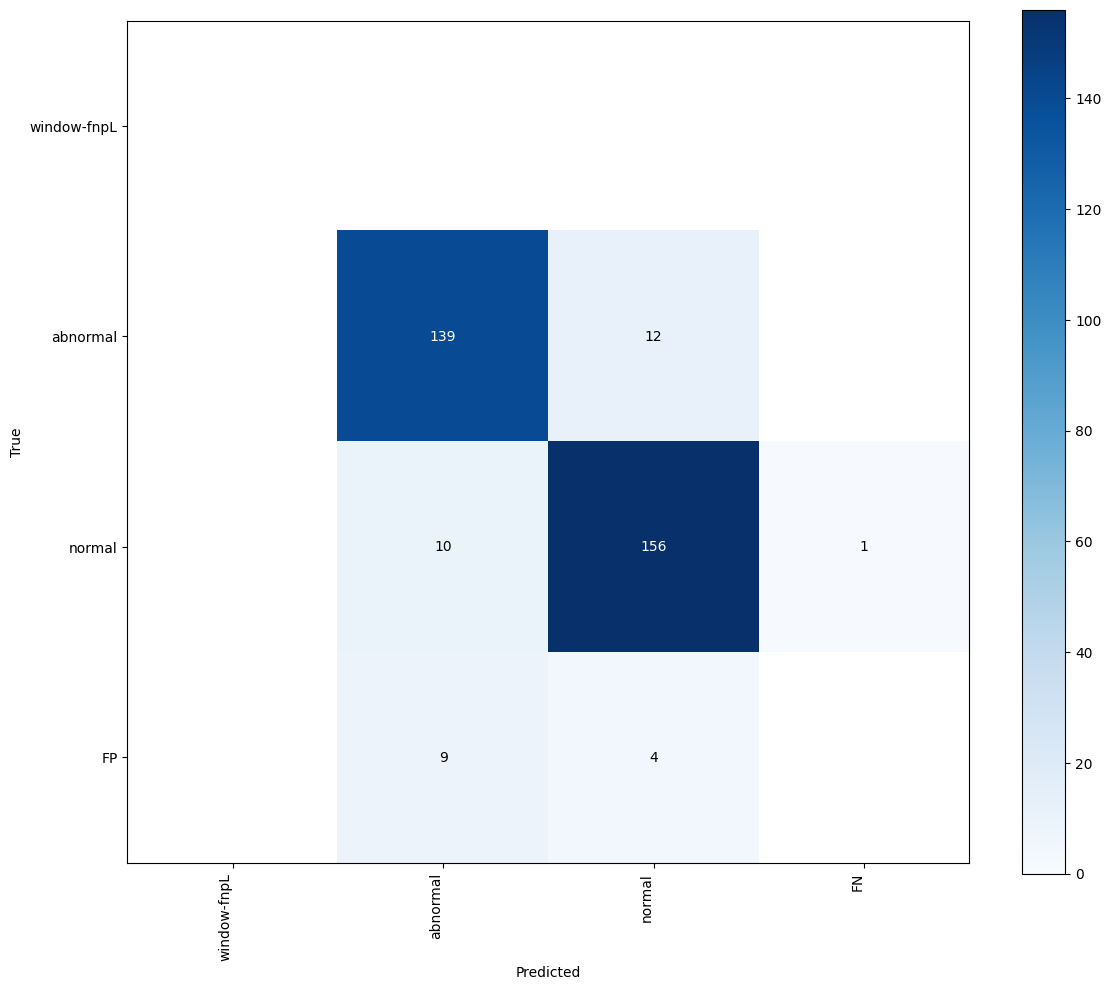

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'confusion_matrix' is already defined from the previous code
confusion_matrix.plot()
plt.savefig("confusion_matrix.png") # Save the plot as a PNG image
plt.show()


### Inference with Custom Model on Videos

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

In [ ]:
!gdown "https://drive.google.com/uc?id=1iMitK9VCUWmBcZiiEPHK1d2pydALof6s&confirm=t"

Downloading...
From: https://drive.google.com/uc?id=1iMitK9VCUWmBcZiiEPHK1d2pydALof6s&confirm=t
To: /content/demo.mp4
100% 4.39M/4.39M [00:00<00:00, 27.8MB/s]


In [ ]:
classes = {1:"pothole"}

In [ ]:
# Define input and output video paths
SOURCE_VIDEO_PATH = "/content/demo.mp4"  # Change this to your input video path
TARGET_VIDEO_PATH = "/content/output_video.mp4"  # Change this to your desired output path

# Create a generator for video frames
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

# Get video information (resolution, fps, etc.)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

# Process the video frame by frame
with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame in tqdm(frame_generator, desc="Processing video"):
        # Get detections using RFDETRBase model
        detections = model.predict(frame, threshold=0.5, iou=0.1)

        # Map numeric class IDs to class names for labels
        labels = []
        for class_id in detections.class_id:
            # Get class name if exists in mapping
            class_name = classes.get(class_id)
            #print("CLass Name", class_name)
            labels.append(class_name)

        # Create annotated frame
        annotated_frame = frame.copy()

        # Apply box annotations
        annotated_frame = sv.BoxAnnotator().annotate(scene=annotated_frame, detections=detections)

        # Apply label annotations with proper class names
        annotated_frame = sv.LabelAnnotator(text_thickness=2).annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels
        )

        # Write the annotated frame to output video
        sink.write_frame(annotated_frame)

print(f"Video processing complete. Output saved to {TARGET_VIDEO_PATH}")

Processing video: 324it [00:26, 12.09it/s]

Video processing complete. Output saved to /content/output_video.mp4


### Display the Output Video

In [ ]:
!rm '/content/result_compressed.mp4'

rm: cannot remove '/content/result_compressed.mp4': No such file or directory


In [ ]:
from IPython.display import HTML
from base64 import b64encode
import os

# Input video path
save_path = f'/content/output_video.mp4'

# Compressed video path
compressed_path = "/content/result_compressed.mp4"

os.system(f"ffmpeg -i {save_path} -vcodec libx264 {compressed_path}")

# Show video
mp4 = open(compressed_path,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

### Load and run fine-tuned model


In [ ]:
!gdown "https://drive.google.com/uc?id=1-3aaHkPwGCy2heR_uvHo_ImQ1loO6T1x&confirm=t"

Downloading...
From: https://drive.google.com/uc?id=1-3aaHkPwGCy2heR_uvHo_ImQ1loO6T1x&confirm=t
To: /content/checkpoint_best_total.pth
100% 369M/369M [00:04<00:00, 74.8MB/s]


Loading pretrain weights


reinitializing detection head with 1 classes


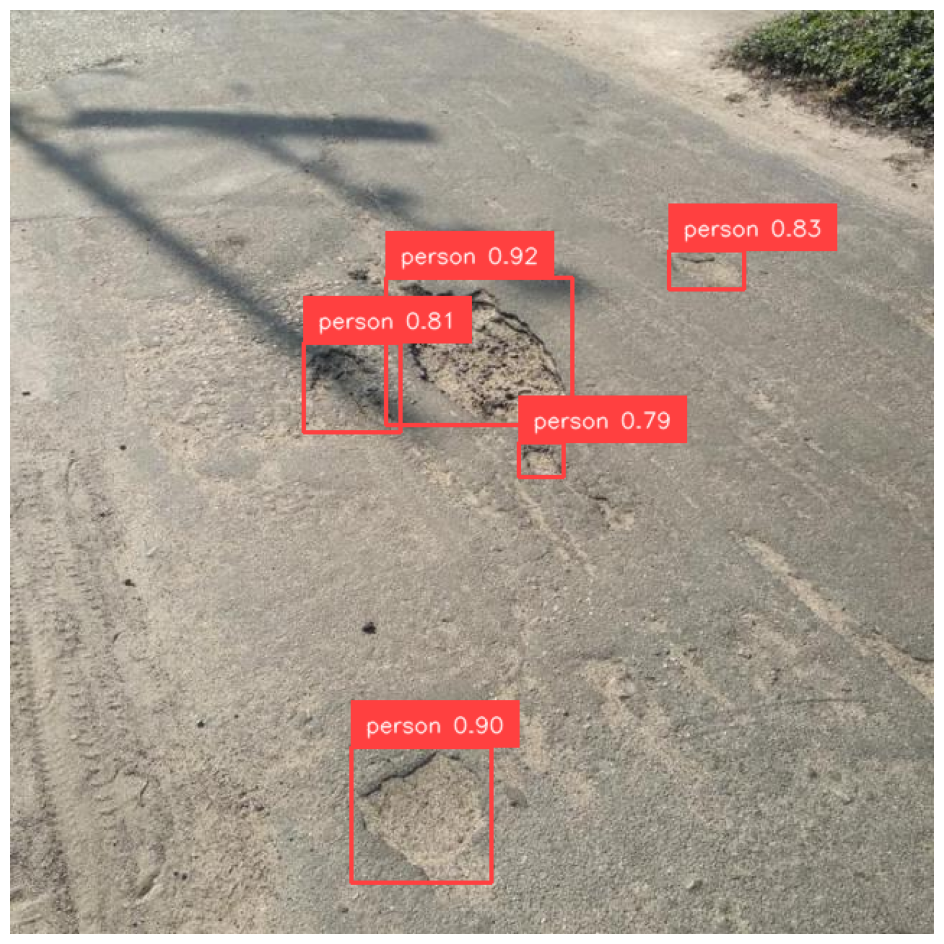

In [ ]:
import io
import requests
import supervision as sv
from PIL import Image
from rfdetr import RFDETRBase
from rfdetr.util.coco_classes import COCO_CLASSES

model = RFDETRBase(pretrain_weights="/content/checkpoint_best_total.pth")

image = Image.open("/content/Potholes-Detection-1/test/img-108_jpg.rf.fb2077bd1f912ba69ff9c156746cc3dc.jpg")
detections = model.predict(image, threshold=0.5)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

sv.plot_image(annotated_image)